# Методы обработки и распознавания изображений 

## Практическое занятие 4: Реализация многослойных нейронных сетей

<h2 style="text-align: center;"><b>Реализация одного нейрона на PyTorch</b></h2>

Рассмотрим особенности программирования нейронных сетей на фреймворке PyTorch, начнем с самого простого - как написать свой нейрон с разными функциями потерь и рассмотрим его работу на конкретных датасетах.

<h3 style="text-align: center;"><b>Компоненты нейросети</b></h3>

При построении любой ***нейронной сети*** для нас важна:  

- непосредственно, сама **архитектура** нейросети (сюда входят типы функций активации у каждого нейрона);
- начальная **инициализация** весов каждого слоя;
- метод **оптимизации** нейросети (сюда ещё входит метод изменения `learning_rate`);
- размер **батчей** (`batch_size`);
- количество **эпох** обучения (`num_epochs`);
- **функция потерь** (`loss`);  
- тип **регуляризации** нейросети (для каждого слоя можно свой);  

То, что связано с ***данными и задачей***:  
- само **качество** выборки (непротиворечивость, чистота, корректность постановки задачи);  
- **размер** выборки;  

<h3 style="text-align: center;"><b>Один нейрон на PyTorch</b></h3>

Будем использовать уже знакомые данные "яблоки и груши":

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
data = pd.read_csv("Яблоки и груши.csv")

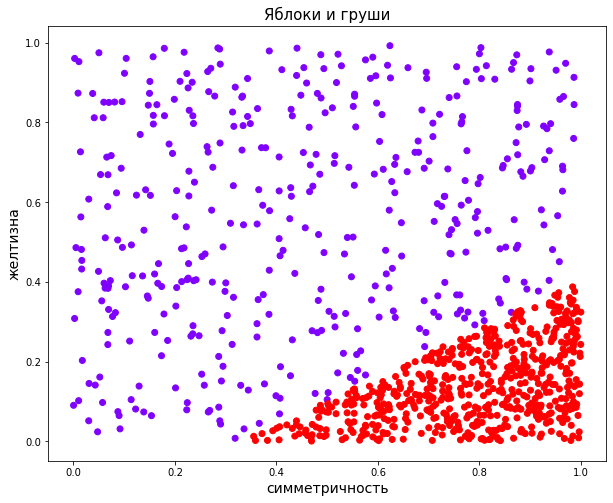

In [11]:
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=data['target'], cmap='rainbow')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

In [12]:
X = data.iloc[:,:2].values  # матрица объекты-признаки
y = data['target'].values.reshape((-1, 1))  # классы (столбец из нулей и единиц)

В модуле torch.nn лежат все необходимые вещи для конструирования нейроных сетей, а в модуле torch.optim - для выбора метода оптимизации нейросети:

In [13]:
import torch
from torch.nn import Linear, Sigmoid

Есть **два пути объявления нейросетей** в PyTorch:  
- ***функциональный (`Functional`);***
- ***последовательный (`Sequential`);***

Рассмотрим второй путь (он чуть более user-friendly) и построим таким способом один нейрон (точно такой же, который мы реализовывали раньше с помощью Numpy):

In [14]:
num_features = X.shape[1]

neuron = torch.nn.Sequential(
    Linear(num_features, out_features=1),
    Sigmoid()
)

In [16]:
neuron

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

Пока что мы просто создали объект класса `Sequential`, который состоит из одного линейного слоя размерности (num_features, 1) и последующего применения сигмоиды. Но уже сейчас его можно применить к объекту (тензору), просто веса в начале инициализирутся случайно и при forward_pass'е мы получим какой-то ответ пока что необученного нейрона:

In [18]:
neuron(torch.autograd.Variable(torch.FloatTensor([1, 1])))

tensor([0.4320], grad_fn=<SigmoidBackward0>)

Предскажем ещё не обученным нейроном:

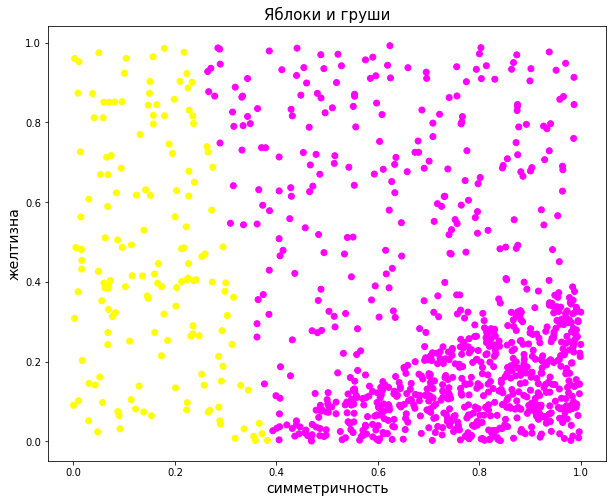

In [19]:
proba_pred = neuron(torch.autograd.Variable(torch.FloatTensor(X)))
y_pred = proba_pred > 0.5
y_pred = y_pred.data.numpy().reshape(-1)

plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=y_pred, cmap='spring')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

Как и ожидалось, ничего полезного. Давайте научим нейрон отличать груши от яблок по их симметричности и желтизне!

Обернём данные в `torch.Tensor`'ы, а тензоры в `torch.Variable`'ы, чтобы можно было вычислять градиенты по весам:

In [20]:
X = torch.autograd.Variable(torch.FloatTensor(X))
y = torch.autograd.Variable(torch.FloatTensor(y))

In [22]:
type(y)

torch.Tensor

Код обучения одного нейрона на PyTorch:

In [30]:
# квадратичная функция потерь (можно сделать другую, например, LogLoss)
loss_fn = torch.nn.MSELoss(size_average=False)

# шаг градиентного спуска (точнее -- метода оптимизации)
learning_rate = 0.01  # == 1e-3
# сам метод оптимизации нейросети (обычно лучше всего по-умолчанию работает Adam)
optimizer = torch.optim.SGD(neuron.parameters(), lr=learning_rate)
# итерируемся num_epochs раз, здесь 500
for t in range(500):
    # foward_pass() -- применение нейросети (этот шаг ещё называют inference)
    y_pred = neuron(X)

    # выведем loss
    loss = loss_fn(y_pred, y)
    print('{} {}'.format(t, loss.data))

    # обнуляем градиенты перед backard_pass'ом (обязательно!)
    optimizer.zero_grad()

    # backward_pass() -- вычисляем градиенты loss'а по параметрам (весам) нейросети
    # этой командой мы только вычисляем градиенты, но ещё не обновляем веса
    loss.backward()

    # а тут уже обновляем веса
    optimizer.step()

0 9.017722129821777
1 9.013445854187012
2 9.009178161621094
3 9.004916191101074
4 9.000662803649902
5 8.996415138244629
6 8.992173194885254
7 8.98793888092041
8 8.983711242675781
9 8.979491233825684
10 8.975278854370117
11 8.971070289611816
12 8.966869354248047
13 8.962675094604492
14 8.958488464355469
15 8.954307556152344
16 8.950133323669434
17 8.945965766906738
18 8.941804885864258
19 8.93764877319336
20 8.933501243591309
21 8.92935848236084
22 8.925225257873535
23 8.921095848083496
24 8.916974067687988
25 8.912858963012695
26 8.908746719360352
27 8.904644966125488
28 8.90054702758789
29 8.896456718444824
30 8.892374038696289
31 8.888296127319336
32 8.884224891662598
33 8.880159378051758
34 8.87610149383545
35 8.872048377990723
36 8.868001937866211
37 8.863962173461914
38 8.859926223754883
39 8.855899810791016
40 8.85187816619873
41 8.847862243652344
42 8.843852996826172
43 8.839850425720215
44 8.835854530334473
45 8.831862449645996
46 8.827877044677734
47 8.823898315429688
48 8.819

Нейрон обучен, теперь выполним классификацию с его помощью:

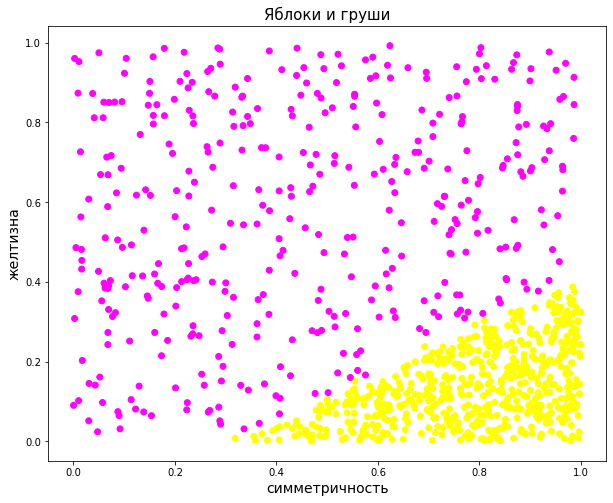

In [31]:
proba_pred = neuron(X)
y_pred = proba_pred > 0.5
y_pred = y_pred.data.numpy().reshape(-1)

plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=y_pred, cmap='spring')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

Можно добиться лучшего качества работы путём изменения `learning_rate` и количества итераций (возможно, еще функции потерь и функции активации). Рекомендуется самостоятельно поэкспериментировать с функцией потерь `torch.nn.NLLLoss()` или `torch.nn.CrossEntropy()`.

---

Обученный нейрон работет, отличает яблоки от груш. Давайте попробуем более сложную выборку данных, которая уже не разделяется линейно:

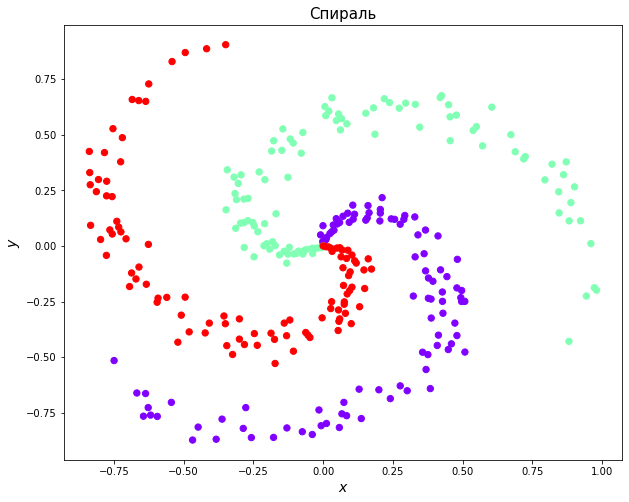

In [32]:
N = 100
D = 2
K = 3
X = np.zeros((N * K, D))
y = np.zeros(N * K, dtype='uint8')

for j in range(K):
    ix = range(N * j,N * (j + 1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4,N) + np.random.randn(N) * 0.2 # theta
    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow)
plt.title('Спираль', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show();

Обработаем данные как и ранее ("оборачиваем" в Variable()):

In [39]:
X = torch.autograd.Variable(torch.FloatTensor(X))
y = torch.autograd.Variable(torch.LongTensor(y.astype(np.int64)))

In [40]:
print(X.data.shape, y.data.shape)

torch.Size([300, 2]) torch.Size([300])


Попробуем нейрон с сигмоидой на линейно неразделимой выборке (точнее в данном случае это уже 3 нейрона с софтмаксом):

In [43]:
# N - размер батча (batch_size, нужно для метода оптимизации)
# D_in - размерность входа (количество признаков у объекта)
# D_out - размерность выходного слоя (суть -- количество классов)
N, D_in, D_out = 64, 2, 3

neuron = torch.nn.Sequential(
    torch.nn.Linear(D_in, D_out),
)

loss_fn = torch.nn.CrossEntropyLoss(size_average=False)

learning_rate = 1e-2
optimizer = torch.optim.SGD(neuron.parameters(), lr=learning_rate)
for t in range(1000):
    # forward
    y_pred = neuron(X)

    # loss
    loss = loss_fn(y_pred, y)
    print('{} {}'.format(t, loss.data))

    # зануляем градиенты с предыдущего шага
    optimizer.zero_grad()

    # backward
    loss.backward()

    # обновляем веса 
    optimizer.step()

0 351.86505126953125
1 314.0864562988281
2 292.5943298339844
3 277.3792419433594
4 266.3458557128906
5 258.1567077636719
6 251.94403076171875
7 247.13710021972656
8 243.3524932861328
9 240.3271026611328
10 237.8760223388672
11 235.86708068847656
12 234.20347595214844
13 232.81341552734375
14 231.6425323486328
15 230.64930725097656
16 229.80137634277344
17 229.0733184814453
18 228.44508361816406
19 227.90036010742188
20 227.42608642578125
21 227.0115509033203
22 226.64794921875
23 226.32803344726562
24 226.04571533203125
25 225.79588317871094
26 225.57420349121094
27 225.3770751953125
28 225.201416015625
29 225.0445556640625
30 224.9042510986328
31 224.7784881591797
32 224.66555786132812
33 224.5640869140625
34 224.47271728515625
35 224.3903045654297
36 224.3159637451172
37 224.24874877929688
38 224.1879425048828
39 224.1328582763672
40 224.08291625976562
41 224.0376434326172
42 223.99647521972656
43 223.95907592773438
44 223.92501831054688
45 223.89404296875
46 223.86581420898438
47 22

535 223.55824279785156
536 223.55824279785156
537 223.55824279785156
538 223.55824279785156
539 223.55824279785156
540 223.55824279785156
541 223.55824279785156
542 223.55824279785156
543 223.55824279785156
544 223.55824279785156
545 223.55824279785156
546 223.55824279785156
547 223.55824279785156
548 223.55824279785156
549 223.55824279785156
550 223.55824279785156
551 223.55824279785156
552 223.55824279785156
553 223.55824279785156
554 223.55824279785156
555 223.55824279785156
556 223.55824279785156
557 223.55824279785156
558 223.55824279785156
559 223.55824279785156
560 223.55824279785156
561 223.55824279785156
562 223.55824279785156
563 223.55824279785156
564 223.55824279785156
565 223.55824279785156
566 223.55824279785156
567 223.55824279785156
568 223.55824279785156
569 223.55824279785156
570 223.55824279785156
571 223.55824279785156
572 223.55824279785156
573 223.55824279785156
574 223.55824279785156
575 223.55824279785156
576 223.55824279785156
577 223.55824279785156
578 223.558

In [44]:
# Переводим обратно в Numpy для отрисовки
X = X.data.numpy()
y = y.data.numpy()

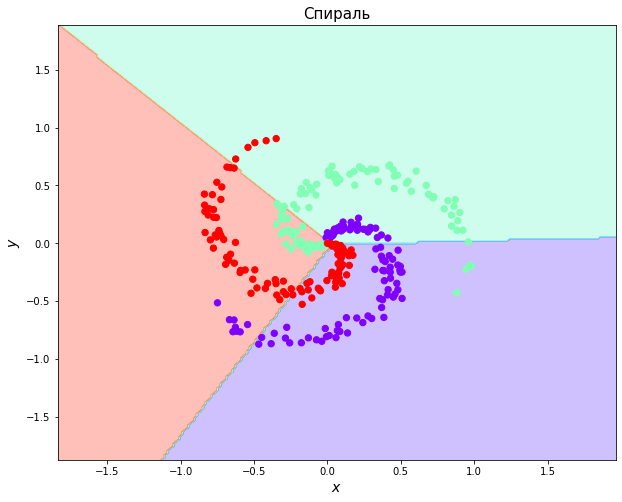

In [45]:
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

Z = neuron(torch.autograd.Variable(grid_tensor))
Z = Z.data.numpy()
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

plt.title('Спираль', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show();

Полученный результат оставляет желать лучшего. Очевидно, что единичные нейроны не способны адекватно обработать подобные данные. Для этого необходимо использовать многослойную нейросеть, которую мы реализуем далее.

Cоздадим двухслойную нейросеть из 100 нейронов

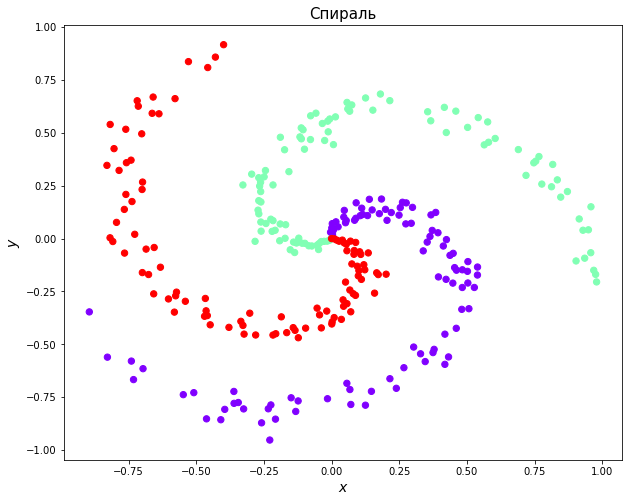

In [46]:
N = 100
D = 2
K = 3
X = np.zeros((N * K, D))
y = np.zeros(N * K, dtype='uint8')

for j in range(K):
    ix = range(N * j,N * (j + 1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4,N) + np.random.randn(N) * 0.2 # theta
    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow)
plt.title('Спираль', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show();

In [57]:
X = torch.autograd.Variable(torch.FloatTensor(X))
y = torch.autograd.Variable(torch.LongTensor(y.astype(np.int64)))

In [58]:
print(X.data.shape, y.data.shape)

torch.Size([300, 2]) torch.Size([300])


In [59]:
# N - размер батча (batch_size, нужно для метода оптимизации); 
# D_in - размерность входа (количество признаков у объекта);
# H - размерность скрытых слоёв; 
# D_out - размерность выходного слоя (суть - количество классов)
N, D_in, H, D_out = 64, 2, 100, 3

# Use the nn package to define our model and loss function.
two_layer_net = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

loss_fn = torch.nn.CrossEntropyLoss(size_average=False)
learning_rate = 1e-4
optimizer = torch.optim.SGD(two_layer_net.parameters(), lr=learning_rate)
for t in range(500):
    # forward
    y_pred = two_layer_net(X)

    # loss
    loss = loss_fn(y_pred, y)
    print('{} {}'.format(t, loss.data))

    # зануляем градиенты (чтобы не было остатка с предыдущего шага)
    optimizer.zero_grad()

    # backward
    loss.backward()

    # обновляем
    optimizer.step()

0 331.3522033691406
1 507.32354736328125
2 1820.8204345703125
3 632.47607421875
4 375.02996826171875
5 297.2012023925781
6 279.6426086425781
7 264.7869873046875
8 251.8751678466797
9 241.62303161621094
10 232.70053100585938
11 225.33224487304688
12 219.14584350585938
13 214.19654846191406
14 211.58131408691406
15 215.23033142089844
16 248.27000427246094
17 310.7935791015625
18 324.8760986328125
19 234.87054443359375
20 213.8821563720703
21 202.86671447753906
22 195.03591918945312
23 190.48699951171875
24 189.530029296875
25 197.15975952148438
26 218.07154846191406
27 246.19107055664062
28 235.9305877685547
29 204.5148468017578
30 199.81661987304688
31 195.91082763671875
32 206.4832000732422
33 203.6368408203125
34 197.09231567382812
35 188.12351989746094
36 176.39610290527344
37 171.74400329589844
38 174.66226196289062
39 191.17335510253906
40 211.22189331054688
41 223.4197540283203
42 171.57398986816406
43 155.80023193359375
44 161.29962158203125
45 205.8234100341797
46 259.1014709472

Обратите внимание: несмотря на то, что это задача 3-х классовой классификации и столбец  𝑦  лучше кодировать OneHotEncoding'ом, мы подали просто столбец из 0, 1 и 2 и всё отработало. Дело в том, что PyTorch сам делает OneHot в таком случае.

Проверим, насколько хороша наша сеть из 100 нейронов:

In [60]:
# Обратно в Numpy для отрисовки
X = X.data.numpy()
y = y.data.numpy()

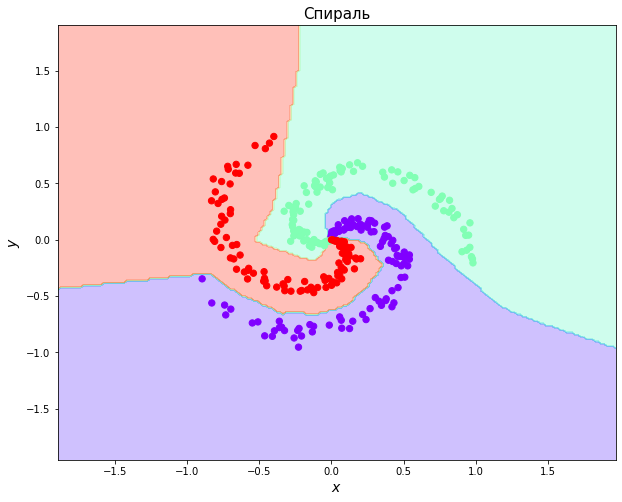

In [61]:
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

Z = two_layer_net(torch.autograd.Variable(grid_tensor))
Z = Z.data.numpy()
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

plt.title('Спираль', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show();

По сравнению с одиночными нейронами конечно же есть разница, но результат очень далек от идеального.

Для получения лучшего результата необходимо выполнить подбор наиболее оптимальных гиперпараметров

In [57]:
X = torch.autograd.Variable(torch.FloatTensor(X))
y = torch.autograd.Variable(torch.LongTensor(y.astype(np.int64)))

In [72]:
N, D_in, H, D_out = 64, 2, 100, 3

better_net = torch.nn.Sequential(
    torch.nn.Linear(D_in, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, D_out),
)

loss_fn = torch.nn.CrossEntropyLoss(size_average=False)

learning_rate = 1e-3
optimizer = torch.optim.SGD(better_net.parameters(), lr=learning_rate)
for t in range(600):
    # forward
    y_pred = better_net(X)

    # loss
    loss = loss_fn(y_pred, y)
    print('{} {}'.format(t, loss.data))

    # зануляем градиенты (чтобы не было остатка с предыдущего шага)
    optimizer.zero_grad()

    # backward
    loss.backward()

    # обновляем
    optimizer.step()

0 329.60089111328125
1 327.4894714355469
2 325.64056396484375
3 323.95703125
4 322.2317810058594
5 320.38134765625
6 318.3764343261719
7 316.19989013671875
8 313.80999755859375
9 311.1748962402344
10 308.26507568359375
11 305.02325439453125
12 301.4330139160156
13 297.5032043457031
14 293.2516174316406
15 288.7046203613281
16 283.9024963378906
17 278.9094543457031
18 273.80389404296875
19 268.66717529296875
20 263.5638122558594
21 258.5516357421875
22 253.67791748046875
23 248.97222900390625
24 244.45565795898438
25 240.12863159179688
26 236.0240936279297
27 232.15704345703125
28 228.50953674316406
29 225.0504150390625
30 221.80963134765625
31 218.8109588623047
32 216.0347137451172
33 213.45062255859375
34 211.0384979248047
35 208.7833251953125
36 206.6910400390625
37 204.84837341308594
38 203.65110778808594
39 204.781982421875
40 215.31240844726562
41 259.0554504394531
42 334.8826599121094
43 297.5810852050781
44 218.44192504882812
45 210.1565704345703
46 204.3191680908203
47 200.2931

380 14.477777481079102
381 14.787784576416016
382 14.399330139160156
383 14.69910717010498
384 14.320496559143066
385 14.611530303955078
386 14.250238418579102
387 14.539626121520996
388 14.178680419921875
389 14.461492538452148
390 14.110300064086914
391 14.385197639465332
392 14.03242015838623
393 14.298380851745605
394 13.951539039611816
395 14.215999603271484
396 13.885971069335938
397 14.14357852935791
398 13.803770065307617
399 14.065132141113281
400 13.738541603088379
401 14.001140594482422
402 13.68026065826416
403 13.947108268737793
404 13.609424591064453
405 13.867703437805176
406 13.525217056274414
407 13.782838821411133
408 13.446211814880371
409 13.676082611083984
410 13.351136207580566
411 13.597704887390137
412 13.285327911376953
413 13.529919624328613
414 13.220137596130371
415 13.465468406677246
416 13.156242370605469
417 13.400461196899414
418 13.107571601867676
419 13.3321533203125
420 13.054522514343262
421 13.2908353805542
422 13.016546249389648
423 13.244552612304

Судя по значениям метрики все дожно быть идеально.

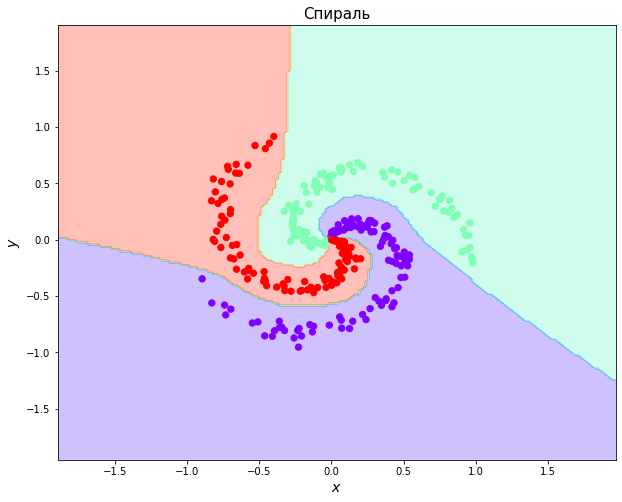

In [73]:
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

Z = better_net(torch.autograd.Variable(grid_tensor))
Z = Z.data.numpy()
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

plt.title('Спираль', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show();

**Дополнительное задание:** Найдите те параметры, которые были изменены и решение стало более адекватным, попробуйте изменить эти параметры и и получить результаты, отличные от представленных выше.